# Eye-Tracking Latency Analysis

### Overview
This notebook processes user study eye-tracking data across **Calibration** and **W1 (Smooth Pursuit)** tasks to evaluate tracking accuracy and signal latency.

### Core Steps
* **Data Cleansing**: Normalizes data structures, filters invalid tracking drops, and applies winsorization to control for extreme outliers.
* **Latency Alignment**: Optimizes gaze signals against target coordinates by identifying and correcting screen transmission lag (up to 30 frames @ 60Hz).
* **Statistical Metrics**: Computes mean values alongside 95% confidence intervals for saccadic, continuous pursuit, and baseline fixation metrics.
* **Visualizations**: Generates time-series coordinate comparisons and error metric distribution plots.


In [1]:
import os
import pathlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
current_dir = pathlib.Path(os.getcwd())
sys.path.append(str(current_dir.parent))

from python_scripts.util import *

In [2]:

analysis_file = get_participant_raw_files("participant-012").get("b5")
df = pd.read_csv(analysis_file)
df = clean_df(df, remove_static=True)

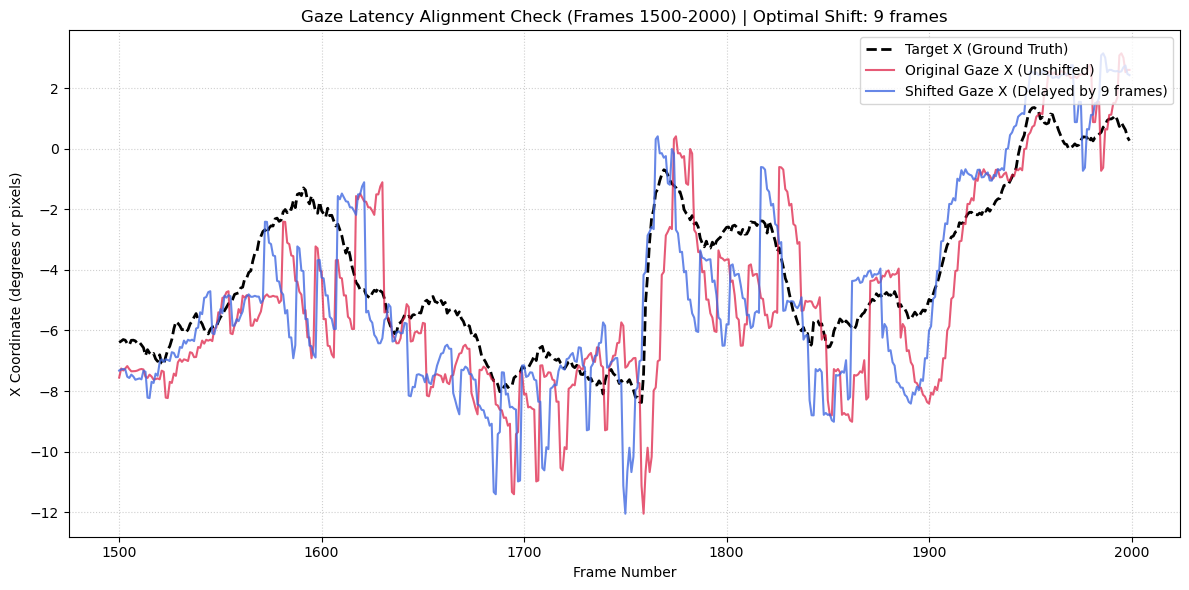

In [3]:
# 1. Get the shifted dataframe and the optimal shift index
shifted_data, optimal_shift = shifted_df(df)

# 2. Extract a segment from the original dataframe
unshifted_segment = df.iloc[1500:2000]

# 3. Extract the same chronological window from the shifted dataframe
shifted_segment = shifted_data.iloc[1500:2000]

# 4. Create the plot
plt.figure(figsize=(12, 6))

plt.plot(unshifted_segment.index, unshifted_segment['target_vis_x'], 
         label='Target X (Ground Truth)', color='black', linewidth=2, linestyle='--')
plt.plot(unshifted_segment.index, unshifted_segment['gaze_vis_x'], 
         label='Original Gaze X (Unshifted)', color='crimson', alpha=0.7)
plt.plot(shifted_segment.index, shifted_segment['gaze_vis_x'], 
         label=f'Shifted Gaze X (Delayed by {optimal_shift} frames)', color='royalblue', alpha=0.8)

# Formatting
plt.title(f'Gaze Latency Alignment Check (Frames 1500-2000) | Optimal Shift: {optimal_shift} frames')
plt.xlabel('Frame Number')
plt.ylabel('X Coordinate (degrees or pixels)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
